# Neural Network Architectures

```{contents}
:local:
:depth: 2
```

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Explain how convolutional, recurrent, and autoencoder architectures impose domain-appropriate
  structure on the learned feature representations.
- Implement a minimal CNN in PyTorch and compare its learned projections to PCA and LDA
  on the MNIST digits dataset.
- Implement an LSTM in PyTorch for time series forecasting and compare its performance
  to the ARIMA model from Topic 6.2.
- Implement a convolutional autoencoder in PyTorch, visualize the latent space, and
  relate it to PCA and generative models from Topic 5.4.
- Select an appropriate architecture for a given data modality using a practical
  decision table.
:::

:::{note}
This chapter uses **PyTorch** for all neural network implementations. If PyTorch is
not installed in your environment, run:

```
conda install pytorch torchvision -c pytorch
```

or `pip install torch torchvision`. All other packages used are standard.
:::

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('../settings/plot_style.mplstyle')

clrs = np.array(['#003057', '#EAAA00', '#4B8B9B', '#B3A369', '#377117',
                 '#1879DB', '#8E8B76', '#F5D580', '#002233'])

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

## The Unifying View: Architecture as Structured Feature Engineering

Every neural network architecture is, at its core, an answer to the question:
*what structure in the data should the feature extractor exploit?*

- **Fully-connected MLP** (Topic 6.3): no structure assumed — every input can interact
  with every other. Best for tabular data where features have no spatial or temporal
  ordering.
- **Convolutional Neural Networks (CNNs)**: input has spatial structure (images,
  spectra, grids). The same filter can be useful anywhere in the image — enforcing
  **translation equivariance** and dramatically reducing parameters.
- **Recurrent Networks / LSTMs**: input is a sequence with temporal dependencies.
  The same computation is applied at each time step with a **shared hidden state**
  that carries information forward.
- **Autoencoders**: learn a compressed representation (latent code) by training the
  network to reconstruct its own input. No labels required — the task is
  **self-supervised**.

The module title "Advanced Topics" reflects a broader truth: architectures are the
feature engineering decisions of deep learning. A well-chosen architecture encodes
domain knowledge that would otherwise need to be hand-crafted.

:::{exercise}
:label: ex-eda-nn-arch-table

Use the unifying view to reason about architecture choice.

For each scenario below, identify the most appropriate architecture from the table
above and give a one-sentence justification:

1. Predicting the next hour's reactor temperature from the past 48 hourly readings.
2. Classifying whether a microscopy image of a catalyst particle contains cracks.
3. Predicting product yield from a 15-column tabular dataset of operating conditions.
4. Detecting anomalous sensor readings in an unlabeled process dataset.
:::

---

## Convolutional Neural Networks

### The Core Idea: Learned Spatial Filters

An image is a 2-D array of pixels. The pixels in a small neighborhood (e.g., 3×3)
are strongly correlated — an edge detector that works at one location should work
at another. CNNs exploit this by applying a **shared filter** (a small matrix of
learnable weights) at every location:

$$(\text{conv}(X, W))_{ij} = \sum_{k,l} X_{i+k,\, j+l} \cdot W_{k,l}$$

A filter that detects a horizontal edge will fire wherever it sees the right intensity
gradient, regardless of where in the image it appears. Stacking multiple filter
channels in each layer builds up a hierarchy: first layer detects edges, second
detects corners, third detects textures, and so on.

**Pooling** (typically max-pooling over 2×2 windows) reduces the spatial resolution
after convolution, providing translation **invariance** (small shifts in the input
do not change the output much) and reducing the number of parameters.

### A Minimal CNN on MNIST Digits

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

digits = load_digits()
X_dig = digits.data.astype(np.float32)   # (1797, 64)
y_dig = digits.target.astype(np.int64)

# Normalize to [0, 1]
X_dig /= 16.0

# Reshape to (N, 1, 8, 8) — channels_first format for PyTorch Conv2d
X_dig_img = X_dig.reshape(-1, 1, 8, 8)

X_tr, X_te, y_tr, y_te = train_test_split(X_dig_img, y_dig, test_size=0.3, random_state=0)

# Convert to PyTorch tensors
X_tr_t = torch.from_numpy(X_tr)
y_tr_t = torch.from_numpy(y_tr)
X_te_t = torch.from_numpy(X_te)
y_te_t = torch.from_numpy(y_te)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

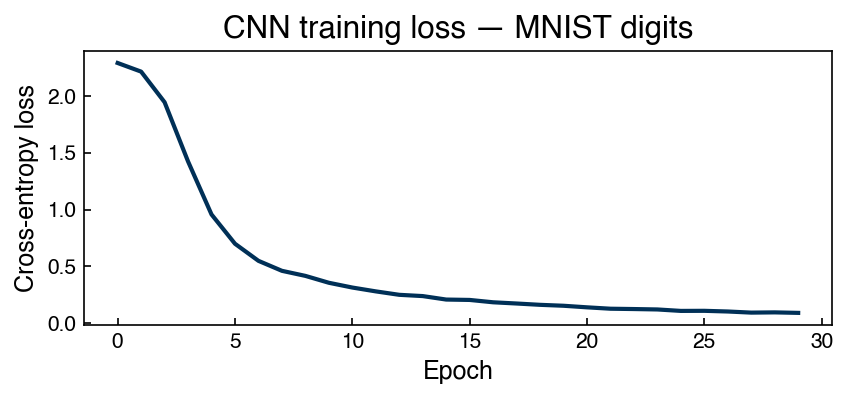

In [3]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),   # (N, 8, 8, 8)
            nn.ReLU(),
            nn.MaxPool2d(2),                               # (N, 8, 4, 4)
            nn.Conv2d(8, 16, kernel_size=3, padding=1),   # (N, 16, 4, 4)
            nn.ReLU(),
            nn.MaxPool2d(2),                               # (N, 16, 2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),            # (N, 64)
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

    def encode(self, x):
        """Return the penultimate (32-D) representation."""
        feats = self.features(x)
        flat  = feats.flatten(1)
        return torch.relu(self.classifier[1](flat))


cnn = SmallCNN()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training loop
losses = []
for epoch in range(30):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(cnn(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(train_loader))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(losses)
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.set_title('CNN training loss — MNIST digits')
plt.tight_layout()

In [4]:
cnn.eval()
with torch.no_grad():
    y_pred = cnn(X_te_t).argmax(dim=1).numpy()

accuracy = (y_pred == y_te).mean()
print(f'CNN test accuracy: {accuracy:.3f}')

CNN test accuracy: 0.957


### Comparing CNN, PCA, and LDA Projections

The intermediate representation of the CNN encodes class information. We can compare
it to unsupervised (PCA) and supervised (LDA) projections:

/var/folders/d5/ylnycwpn6szdb0t1n25l0d_40000gn/T/ipykernel_3808/2142271274.py:37: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/DA4CHE/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  func(*args, **kwargs)
/opt/homebrew/Caskroom/miniforge/base/envs/DA4CHE/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


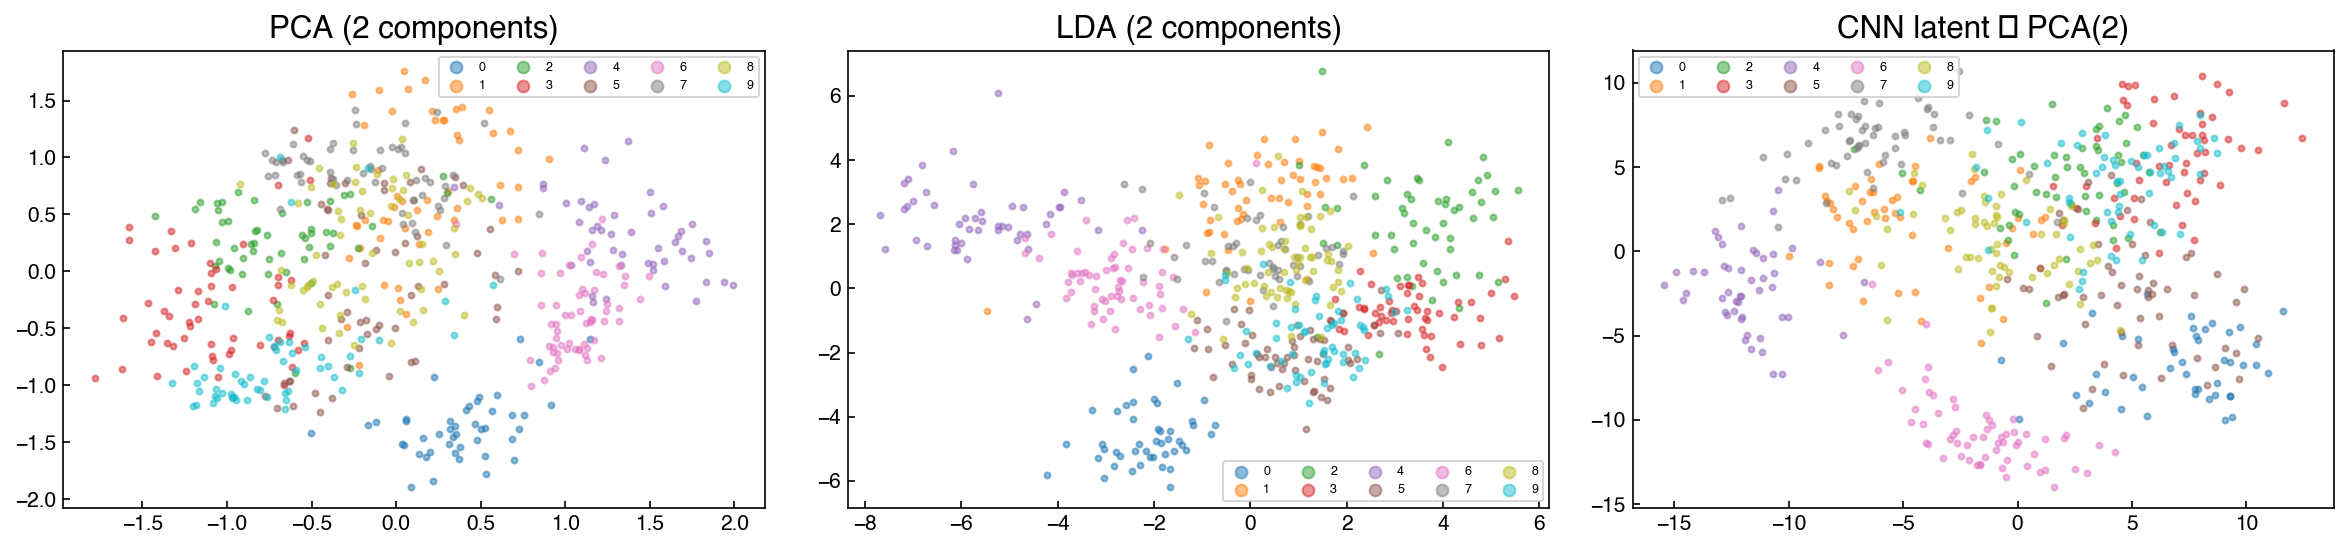

In [5]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# CNN latent features (32-D, penultimate layer)
cnn.eval()
with torch.no_grad():
    cnn_feats = cnn.encode(X_te_t).numpy()

# PCA projection
pca = PCA(n_components=2).fit(X_tr.reshape(len(X_tr), -1))
X_te_pca = pca.transform(X_te.reshape(len(X_te), -1))

# LDA projection
lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(X_tr.reshape(len(X_tr), -1), y_tr)
X_te_lda = lda.transform(X_te.reshape(len(X_te), -1))

# CNN: project to 2D with PCA for visualization
pca2 = PCA(n_components=2).fit(cnn_feats)
X_te_cnn2d = pca2.transform(cnn_feats)

tab10 = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for method, X_2d, title in zip(
    [0, 1, 2],
    [X_te_pca, X_te_lda, X_te_cnn2d],
    ['PCA (2 components)', 'LDA (2 components)', 'CNN latent → PCA(2)'],
):
    for label in range(10):
        mask = y_te == label
        axes[method].scatter(X_2d[mask, 0], X_2d[mask, 1],
                              color=tab10[label], alpha=0.5, s=8, label=str(label))
    axes[method].set_title(title)
    axes[method].legend(ncol=5, fontsize=6, markerscale=2)

plt.tight_layout()

LDA and CNN projections typically show better cluster separation than PCA because both
use label information — LDA explicitly, CNN implicitly through the classification loss.

:::{exercise}
:label: ex-eda-nn-cnn-filters

Inspect the learned filters of the trained CNN.

1. Extract the first convolutional layer weights from `cnn.features[0].weight.data`
   (shape: `[8, 1, 3, 3]`). Plot all 8 filters as 3×3 grayscale images in a single
   figure.
2. For each filter, apply it manually to one test image using
   `torch.nn.functional.conv2d` and visualize the output feature map.
3. Do any filters visually resemble edge detectors (horizontal, vertical, or diagonal
   edges)? Describe what you observe.
:::

---

## Recurrent Networks and LSTMs

### The Vanishing Gradient Problem

For sequence data, a natural idea is to process one element at a time with a shared
network, carrying a **hidden state** $\mathbf{h}_t$ forward:

$$\mathbf{h}_t = \sigma(W_h \mathbf{h}_{t-1} + W_x \mathbf{x}_t + \mathbf{b})$$

A simple Recurrent Neural Network (RNN) can learn short-range dependencies, but
suffers from the **vanishing gradient problem**: during backpropagation, gradients
are multiplied by $W_h$ at every step. If the largest eigenvalue of $W_h$ is $< 1$,
gradients shrink exponentially with sequence length, making it impossible to learn
long-range dependencies.

### LSTM: Gated Memory

The **Long Short-Term Memory (LSTM)** cell addresses this with a **cell state** $c_t$
that can carry information over many steps without multiplicative decay, controlled
by three **gates**:

| Gate | Symbol | Purpose |
|---|---|---|
| **Forget gate** | $f_t = \sigma(W_f[\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_f)$ | What to erase from cell state |
| **Input gate** | $i_t = \sigma(W_i[\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_i)$ | What new information to write |
| **Output gate** | $o_t = \sigma(W_o[\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_o)$ | What to read from cell state |

The cell state update is:

$$\tilde{c}_t = \tanh(W_c[\mathbf{h}_{t-1}, \mathbf{x}_t] + \mathbf{b}_c)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$\mathbf{h}_t = o_t \odot \tanh(c_t)$$

Because the cell state is updated by **addition** (not multiplication), gradients
can flow through many steps without vanishing.

### LSTM Forecasting: Dow Impurity

We apply an LSTM to the same Dow impurity data used in Topics 6.1–6.2. As in ARIMA,
we use a chronological train/test split:

In [6]:
# Load Dow impurity time series
df_dow = pd.read_excel('data/impurity_dataset-training.xlsx')
dow_df = df_dow[['Date', 'y:Impurity']].copy()
dow_df['Date'] = pd.to_datetime(dow_df['Date'])
dow_df = dow_df.set_index('Date').dropna()

impurity = dow_df['y:Impurity'].values.astype(np.float32)
print(f'Dow series length: {len(impurity)}')

Dow series length: 10703


In [7]:
def make_windows(series, window_size):
    """Create overlapping input windows and targets for sequence modeling."""
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i : i + window_size])
        y.append(series[i + window_size])
    return np.array(X), np.array(y)

# Normalize
mu, sigma_s = impurity.mean(), impurity.std()
impurity_norm = (impurity - mu) / sigma_s

window = 24   # 24 hourly observations as context
X_seq, y_seq = make_windows(impurity_norm, window)

# Chronological split
split = int(0.8 * len(X_seq))
X_tr_seq, X_te_seq = X_seq[:split], X_seq[split:]
y_tr_seq, y_te_seq = y_seq[:split], y_seq[split:]

# Reshape to (N, seq_len, features=1) for PyTorch LSTM
X_tr_t = torch.tensor(X_tr_seq).unsqueeze(-1)
y_tr_t = torch.tensor(y_tr_seq).unsqueeze(-1)
X_te_t = torch.tensor(X_te_seq).unsqueeze(-1)
y_te_t = torch.tensor(y_te_seq).unsqueeze(-1)

lstm_train_ds = TensorDataset(X_tr_t, y_tr_t)
lstm_loader   = DataLoader(lstm_train_ds, batch_size=64, shuffle=True)

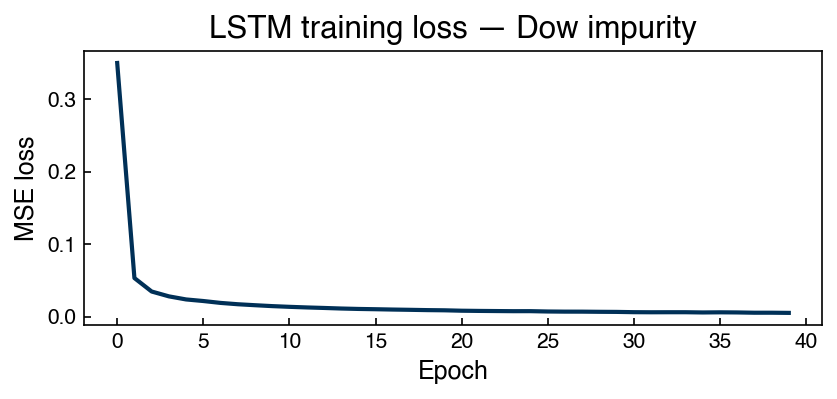

In [8]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm   = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])   # use last hidden state

lstm_model = LSTMForecaster(hidden_size=32)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion  = nn.MSELoss()

lstm_losses = []
for epoch in range(40):
    epoch_loss = 0.0
    for xb, yb in lstm_loader:
        optimizer.zero_grad()
        loss = criterion(lstm_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    lstm_losses.append(epoch_loss / len(lstm_loader))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(lstm_losses)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('LSTM training loss — Dow impurity')
plt.tight_layout()

LSTM test MAE: 0.0383
LSTM test r²:  0.993


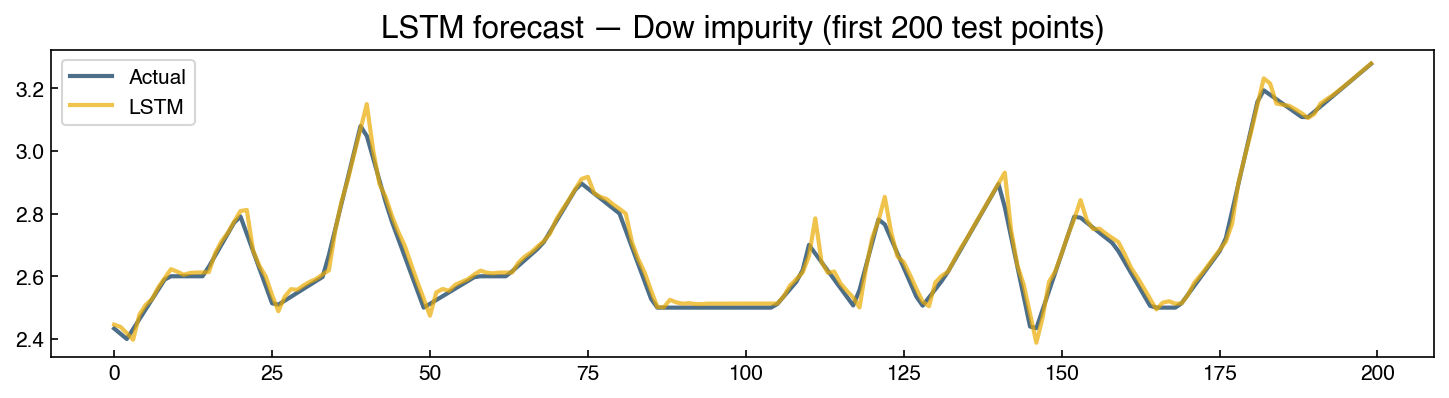

In [9]:
lstm_model.eval()
with torch.no_grad():
    y_pred_norm = lstm_model(X_te_t).squeeze().numpy()

# Denormalize
y_pred = y_pred_norm * sigma_s + mu
y_true = y_te_seq * sigma_s + mu

mae_lstm = np.mean(np.abs(y_pred - y_true))
ss_res = np.sum((y_pred - y_true)**2)
ss_tot = np.sum((y_true - y_true.mean())**2)
r2_lstm = 1 - ss_res / ss_tot

print(f'LSTM test MAE: {mae_lstm:.4f}')
print(f'LSTM test r²:  {r2_lstm:.3f}')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(y_true[:200], label='Actual', alpha=0.7)
ax.plot(y_pred[:200], label='LSTM', alpha=0.7)
ax.set_title('LSTM forecast — Dow impurity (first 200 test points)')
ax.legend()
plt.tight_layout()

:::{note}
The LSTM uses a **one-step-ahead** sliding window forecast (predicting the next value
given the previous 24). This is comparable to the AR model from Topic 6.2. For a fair
comparison with ARIMA, the same window-based approach should be used with the ARIMA
model. LSTMs often outperform ARIMA when the series has complex nonlinear patterns or
when many training examples are available.
:::

:::{exercise}
:label: ex-eda-nn-lstm-window

Investigate the effect of window size on LSTM forecasting performance.

1. Using the same Dow impurity series and training setup as above, train
   `LSTMForecaster` with window sizes `[8, 16, 24, 48]` (keep `hidden_size=32`,
   40 epochs, `random_state=0` via `torch.manual_seed(0)`).
2. For each window size, report the test MAE and test $r^2$.
3. Plot the test MAE vs. window size. Is there a window size that clearly minimizes
   MAE? What does this suggest about the effective memory of the Dow series?
:::

---

## Autoencoders

### Encoder–Decoder Architecture

An **autoencoder** is a neural network trained to reconstruct its own input through a
**bottleneck** — a low-dimensional **latent code** $\mathbf{z}$:

$$\mathbf{z} = \text{Encoder}(\mathbf{x}) \in \mathbb{R}^k, \quad \hat{\mathbf{x}} = \text{Decoder}(\mathbf{z}) \in \mathbb{R}^p$$

The training objective is to minimize reconstruction loss:

$$\mathcal{L} = \|\mathbf{x} - \hat{\mathbf{x}}\|^2$$

Since no labels are required, autoencoders are **unsupervised** (or self-supervised).
They learn to compress the input into the most informative representation that still
allows faithful reconstruction.

**Connections to other methods in this course:**
- When both encoder and decoder are linear, PCA is the exact optimal solution.
- When the decoder is replaced by a generative model (Gaussian, flow), autoencoders
  generalize to VAEs (variational autoencoders) and connect to the GMM/KDE generative
  models of Topic 5.4.

### Autoencoder on MNIST Digits

In [10]:
# Flatten the 8x8 images to 64-D for this simple FC autoencoder
X_ae_tr = torch.tensor(X_tr.reshape(len(X_tr), -1))  # (N_tr, 64)
X_ae_te = torch.tensor(X_te.reshape(len(X_te), -1))

ae_loader = DataLoader(TensorDataset(X_ae_tr), batch_size=64, shuffle=True)

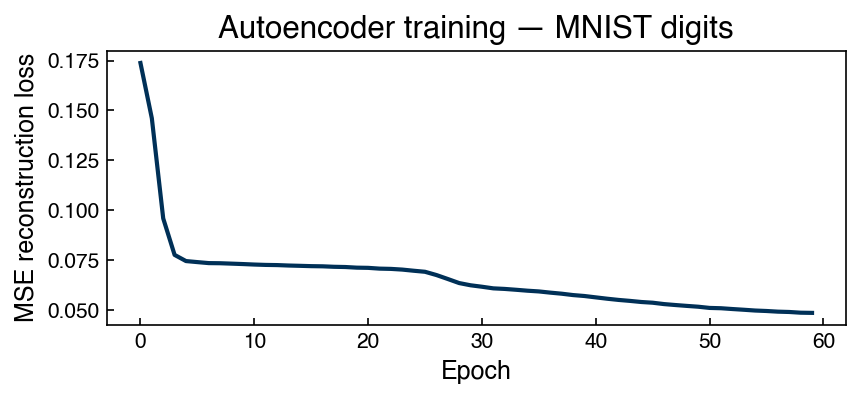

In [11]:
LATENT_DIM = 2   # 2-D latent space for easy visualization

class Autoencoder(nn.Module):
    def __init__(self, input_dim=64, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, input_dim), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

ae = Autoencoder()
opt_ae = torch.optim.Adam(ae.parameters(), lr=1e-3)
crit_ae = nn.MSELoss()

ae_losses = []
for epoch in range(60):
    epoch_loss = 0.0
    for (xb,) in ae_loader:
        opt_ae.zero_grad()
        loss = crit_ae(ae(xb), xb)
        loss.backward()
        opt_ae.step()
        epoch_loss += loss.item()
    ae_losses.append(epoch_loss / len(ae_loader))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ae_losses)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE reconstruction loss')
ax.set_title('Autoencoder training — MNIST digits')
plt.tight_layout()

In [12]:
ae.eval()
with torch.no_grad():
    z_te = ae.encoder(X_ae_te).numpy()   # latent codes
    X_recon = ae(X_ae_te).numpy()        # reconstructions

# Reconstruction error
recon_mse = np.mean((X_ae_te.numpy() - X_recon)**2)
print(f'Test reconstruction MSE: {recon_mse:.5f}')

Test reconstruction MSE: 0.05021


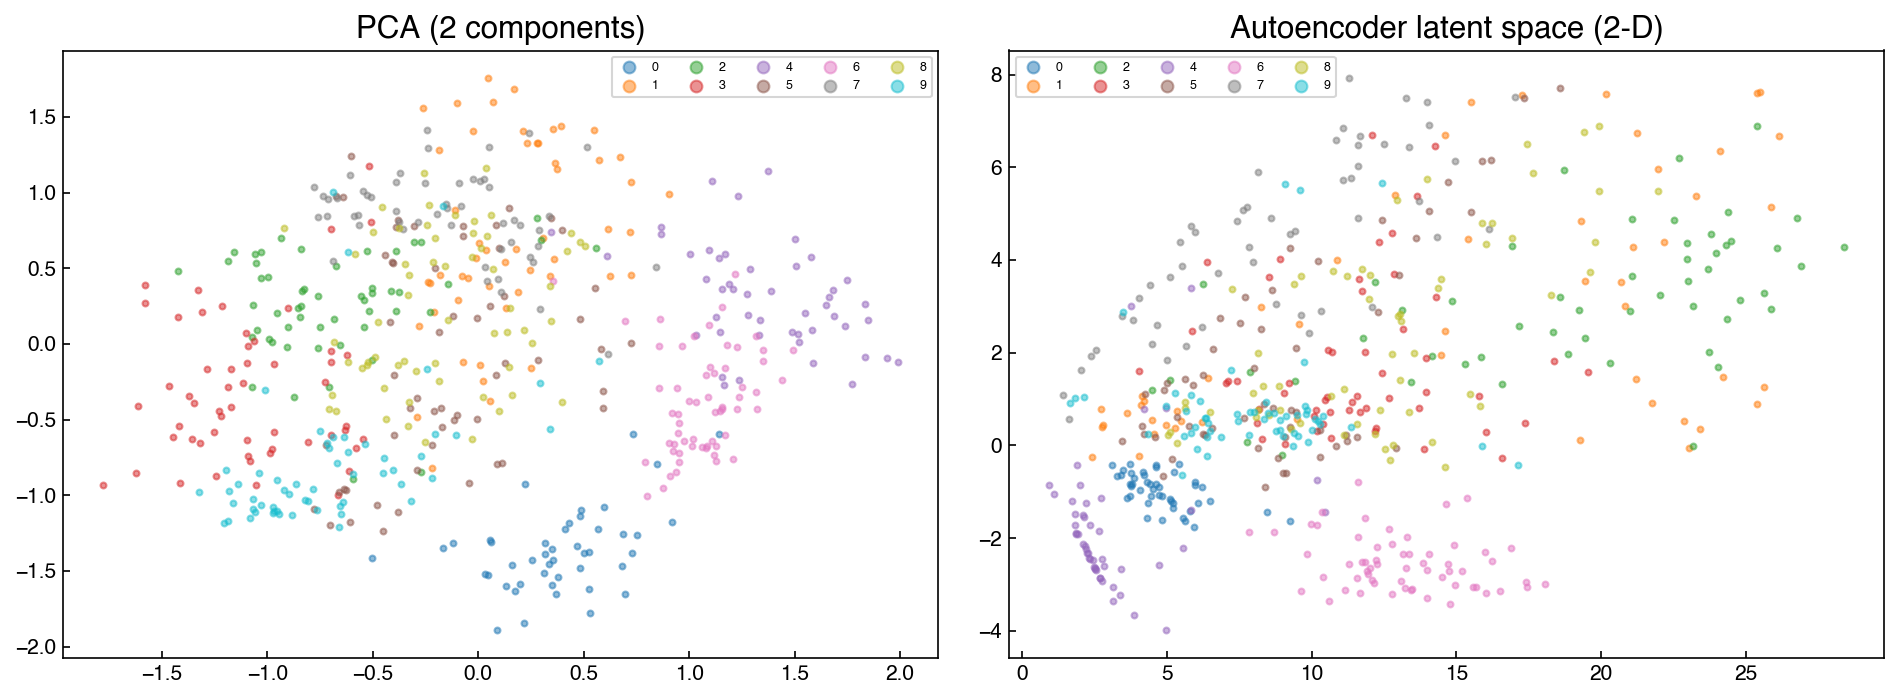

In [13]:
# Visualize 2-D latent space — compare to PCA
pca_ae = PCA(n_components=2).fit(X_ae_tr.numpy())
z_pca  = pca_ae.transform(X_ae_te.numpy())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for label in range(10):
    mask = y_te == label
    axes[0].scatter(z_pca[mask, 0], z_pca[mask, 1],
                    color=tab10[label], alpha=0.5, s=8, label=str(label))
    axes[1].scatter(z_te[mask, 0], z_te[mask, 1],
                    color=tab10[label], alpha=0.5, s=8, label=str(label))

axes[0].set_title('PCA (2 components)')
axes[1].set_title('Autoencoder latent space (2-D)')
for ax in axes:
    ax.legend(ncol=5, fontsize=6, markerscale=2)
plt.tight_layout()

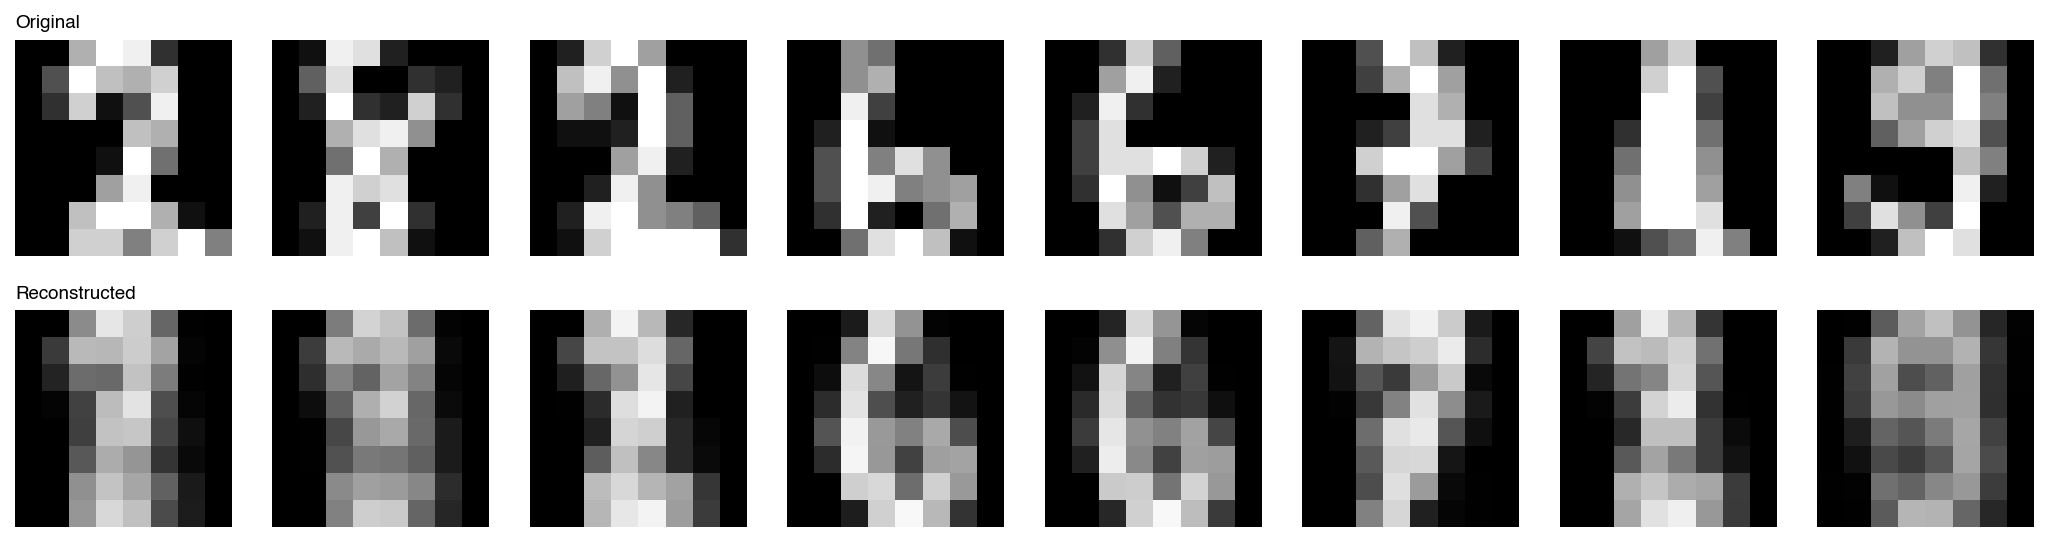

In [14]:
# Visualize original vs. reconstructed digits
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(X_ae_te[i].numpy().reshape(8, 8), cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(X_recon[i].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].axis('off')

axes[0, 0].set_title('Original', loc='left', fontsize=9)
axes[1, 0].set_title('Reconstructed', loc='left', fontsize=9)
plt.tight_layout()

The autoencoder's 2-D latent space clusters digits by class — even though no labels
were used during training. The clusters tend to be less separated than PCA or LDA
because the objective (reconstruction) is not directly aligned with class separation.
Increasing the latent dimension or adding a classification loss would tighten the
clustering.

:::{exercise}
:label: ex-eda-nn-ae

Extend the autoencoder experiment.

1. Increase `LATENT_DIM` to 8 and retrain. Does the reconstruction MSE improve?
   Plot a few original and reconstructed digits.
2. With `LATENT_DIM=2`, fit a `KNeighborsClassifier` (k=5) on the latent codes of the
   training set and evaluate on the test set. How does this accuracy compare to
   fitting KNN on the raw 64-D pixel data?
3. Fit PCA to 2 components and then train KNN on the PCA projections. Compare
   accuracy: raw → KNN, AE latent → KNN, PCA → KNN.
4. Based on results 2–3, which representation (AE latent, PCA, raw) is most useful
   for nearest-neighbor classification? Explain in terms of the information each
   representation preserves.
:::

---

## Choosing an Architecture

| Data type | Recommended architecture | Rationale |
|---|---|---|
| Tabular (no spatial/temporal order) | MLP | All features can interact freely |
| Images, spectra, 1-D signals with spatial structure | CNN | Translation equivariance reduces parameters |
| Sequences with long-range dependencies | LSTM / Transformer | Gated cell state avoids vanishing gradient |
| Short sequences, simple patterns | AR or ARIMA | Lower complexity, interpretable, fast to train |
| Unlabeled data, anomaly detection, generation | Autoencoder / VAE | Self-supervised; latent space is useful for downstream tasks |
| Small dataset ($n < 1000$) | Kernel SVM, GPR, GBT | Deep learning is data-hungry; classical methods generalize better |

**Practical rules of thumb:**
- Neural networks require more data than classical methods to avoid overfitting. As a
  rough guide, you need at least 10–100× as many training samples as model parameters.
- Start with the simplest model that could work. An ARIMA forecast takes seconds to
  fit; an LSTM takes minutes. If ARIMA achieves adequate accuracy, use it.
- CNNs almost always outperform MLPs on image data — even a small CNN with shared
  filters has far fewer parameters than an MLP on the same input size.

:::{exercise}
:label: ex-eda-nn-cnn-vs-mlp

Compare CNN and MLP on the MNIST digits dataset.

1. Build a fully-connected `MLPClassifier` with `hidden_layer_sizes=(64, 32)` and
   fit it on the flattened 64-D digit images (`X_tr.reshape(len(X_tr), -1)`).
   Report test accuracy.
2. Count the number of trainable parameters in the MLP vs. the `SmallCNN` defined
   above. (For the CNN, sum `p.numel()` for `p in cnn.parameters()`.)
3. The CNN uses far fewer parameters than the MLP but achieves similar or better
   accuracy. Explain in two sentences why shared convolutional filters are more
   parameter-efficient than fully-connected layers for image data.
:::

---

## Summary

- **Architecture is structured feature engineering**: CNNs exploit spatial locality,
  LSTMs exploit temporal dependence, autoencoders exploit self-similarity — each
  architecture encodes domain-specific inductive biases that reduce the effective
  search space for the optimizer.

- **CNNs** apply shared filters across spatial positions, learning hierarchical visual
  features. Even a tiny CNN on 8×8 digit images achieves competitive accuracy with far
  fewer parameters than a fully-connected MLP.

- **LSTMs** use a gated cell state to carry information over long sequences, avoiding
  the vanishing gradient that limits simple RNNs. They are well suited to industrial
  time series where ARIMA underfits complex nonlinear dynamics.

- **Autoencoders** learn a compressed, task-agnostic representation by minimizing
  reconstruction loss. The latent space generalizes PCA (linear autoencoders reduce
  to PCA exactly) and connects to generative models from Topic 5.4.

- **Architecture selection** should be driven by data modality and dataset size.
  For tabular engineering data, classical methods and MLPs often suffice; CNNs and
  LSTMs become valuable when spatial or temporal structure is present and enough
  data is available to exploit it.

## Additional Reading

- Goodfellow, I., Bengio, Y. & Courville, A. (2016), *Deep Learning*, Chapters 9 (CNNs),
  10 (RNNs), 14 (Autoencoders) — [deeplearningbook.org](https://www.deeplearningbook.org/)
- LeCun, Y., Bengio, Y. & Hinton, G. (2015), "Deep learning," *Nature* 521, 436–444 —
  accessible survey of CNNs and RNNs
- Hochreiter, S. & Schmidhuber, J. (1997), "Long Short-Term Memory," *Neural Computation*
  9(8), 1735–1780 — original LSTM paper
- PyTorch tutorials: [pytorch.org/tutorials](https://pytorch.org/tutorials/)